# CAPM & Fama-French 3 Facteurs — CAC 40
### Beta, Alpha de Jensen, SMB et HML sur les 40 valeurs de l'indice français

Ce notebook applique les deux grands modèles de pricing des actifs financiers
aux **40 composantes exactes du CAC 40** avec des données réelles via **yfinance**
et les facteurs européens de la **bibliothèque Ken French**.

| Modèle | Formule | Facteurs |
|--------|---------|----------|
| **CAPM** | $r_i - r_f = \alpha + \beta(r_m - r_f) + \varepsilon$ | Marché |
| **Fama-French** | $r_i - r_f = \alpha + \beta^{Mkt}(r_m-r_f) + \beta^{SMB}\cdot SMB + \beta^{HML}\cdot HML + \varepsilon$ | Marché + Taille + Valeur |

**Plan :** données → performance → corrélations (heatmaps) → CAPM → Fama-French → synthèse

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import yfinance as yf
import statsmodels.api as sm
import warnings

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11, "axes.titlesize": 13})

## 1. Composition historique du CAC 40 (2019–2024)

In [32]:
# ── Univers historique du CAC 40 (2019–2024) ─────────────────────────────────
# Format : (ticker, secteur, entrée_dans_l'indice, sortie_de_l'indice)
# None = avant jan 2019 / après déc 2024
CAC40_HISTORY = [
    # ── Présents sur toute la période ────────────────────────────────────────
    ("MC.PA",    "Luxe",          None,         None),          # LVMH
    ("RMS.PA",   "Luxe",          None,         None),          # Hermès
    ("KER.PA",   "Luxe",          None,         None),          # Kering
    ("OR.PA",    "Consommation",  None,         None),          # L'Oréal
    ("BN.PA",    "Consommation",  None,         None),          # Danone
    ("RI.PA",    "Consommation",  None,         None),          # Pernod Ricard
    ("CA.PA",    "Consommation",  None,         None),          # Carrefour
    ("BNP.PA",   "Finance",       None,         None),          # BNP Paribas
    ("ACA.PA",   "Finance",       None,         None),          # Crédit Agricole
    ("GLE.PA",   "Finance",       None,         None),          # Société Générale
    ("CS.PA",    "Finance",       None,         None),          # AXA
    ("TTE.PA",   "Énergie",       None,         None),          # TotalEnergies
    ("ENGI.PA",  "Énergie",       None,         None),          # Engie
    ("SAN.PA",   "Santé",         None,         None),          # Sanofi
    ("EL.PA",    "Santé",         None,         None),          # EssilorLuxottica
    ("ERF.PA",   "Santé",         None,         None),          # Eurofins Scientific
    ("AIR.PA",   "Industrie",     None,         None),          # Airbus
    ("SAF.PA",   "Industrie",     None,         None),          # Safran
    ("HO.PA",    "Industrie",     None,         None),          # Thales
    ("SU.PA",    "Industrie",     None,         None),          # Schneider Electric
    ("LR.PA",    "Industrie",     None,         None),          # Legrand
    ("DG.PA",    "Industrie",     None,         None),          # Vinci
    ("EN.PA",    "Industrie",     None,         None),          # Bouygues
    ("AI.PA",    "Industrie",     None,         None),          # Air Liquide
    ("CAP.PA",   "Technologie",   None,         None),          # Capgemini
    ("DSY.PA",   "Technologie",   None,         None),          # Dassault Systèmes
    ("STM.PA",   "Technologie",   None,         None),          # STMicroelectronics
    ("RNO.PA",   "Automobile",    None,         None),          # Renault
    ("ML.PA",    "Automobile",    None,         None),          # Michelin
    ("MT.PA",    "Matériaux",     None,         None),          # ArcelorMittal
    ("SGO.PA",   "Matériaux",     None,         None),          # Saint-Gobain
    ("VIE.PA",   "Services",      None,         None),          # Veolia
    ("ORA.PA",   "Télécom",       None,         None),          # Orange
    ("PUB.PA",   "Communication", None,         None),          # Publicis
    ("TEP.PA",   "Services",      None,         None),          # Teleperformance (→ sept 2025)
    # ── Présence partielle ────────────────────────────────────────────────────
    ("URW.AS",   "Immobilier",    None,         "2020-11-20"),  # URW : sort nov 2020 (cote Amsterdam)
    ("UG.PA",    "Automobile",    None,         "2021-01-18"),  # PSA : fusionné en Stellantis
    ("STLAM.PA", "Automobile",    "2021-01-18", None),          # Stellantis : dès jan 2021
    ("WLN.PA",   "Technologie",   "2020-03-23", "2023-12-18"),  # Worldline
    ("VIV.PA",   "Communication", None,         "2023-06-19"),  # Vivendi : sort juin 2023
    ("ALO.PA",   "Industrie",     "2021-09-20", "2024-03-18"),  # Alstom (post-Bombardier → mars 2024)
    ("EDEN.PA",  "Services",      "2023-06-19", None),          # Edenred : dès juin 2023
    ("AC.PA",    "Hôtellerie",    "2024-03-18", None),          # Accor : dès mars 2024
]

SECTOR_COLORS = {
    "Luxe":          "#c0392b",
    "Finance":       "#2980b9",
    "Industrie":     "#27ae60",
    "Technologie":   "#8e44ad",
    "Énergie":       "#e67e22",
    "Santé":         "#16a085",
    "Consommation":  "#f39c12",
    "Matériaux":     "#7f8c8d",
    "Automobile":    "#d35400",
    "Services":      "#1abc9c",
    "Télécom":       "#2c3e50",
    "Communication": "#e74c3c",
    "Hôtellerie":    "#9b59b6",
    "Immobilier":    "#34495e",
}

tickers = [t for t, *_ in CAC40_HISTORY]
sectors  = pd.Series({t: s for t, s, *_ in CAC40_HISTORY}, name="Secteur")

print(f"Univers historique : {len(tickers)} valeurs (2019–2024)")
print("\nRépartition par secteur :")
print(sectors.value_counts().to_string())

Univers historique : 43 valeurs (2019–2024)

Répartition par secteur :
Secteur
Industrie        9
Consommation     4
Finance          4
Technologie      4
Automobile       4
Luxe             3
Santé            3
Services         3
Énergie          2
Matériaux        2
Communication    2
Télécom          1
Immobilier       1
Hôtellerie       1


In [33]:
START = "2019-01-01"
END   = "2024-12-31"
period_start = pd.Timestamp(START)
period_end   = pd.Timestamp(END)

# Masques de présence dans l'indice pour chaque titre
membership = {
    ticker: (
        pd.Timestamp(entry) if entry else period_start,
        pd.Timestamp(exit_) if exit_ else period_end,
    )
    for ticker, _, entry, exit_ in CAC40_HISTORY
}

raw = yf.download(tickers + ["^FCHI"], start=START, end=END,
                  auto_adjust=True, progress=False)["Close"]
raw = raw.rename(columns={"^FCHI": "CAC40"})
raw = raw.ffill().dropna(how="all")

# Masquer les cours hors période d'appartenance à l'indice
for ticker, (in_date, out_date) in membership.items():
    if ticker in raw.columns:
        raw.loc[raw.index < in_date,  ticker] = np.nan
        raw.loc[raw.index > out_date, ticker] = np.nan

available = [t for t in tickers if t in raw.columns]
sectors   = sectors[sectors.index.isin(available)]

# Conserver toutes les dates de marché (pas de dropna global sur les titres)
prices     = raw[available + ["CAC40"]].dropna(subset=["CAC40"])
returns    = prices.pct_change().dropna(subset=["CAC40"])
stock_ret  = returns[available]
market_ret = returns["CAC40"]

print(f"Période    : {prices.index[0].date()} → {prices.index[-1].date()}")
print(f"Valeurs    : {len(available)} titres dans l'univers historique")
print(f"Jours      : {len(prices)} jours de cotation\n")

missing = [t for t in tickers if t not in raw.columns]
if missing:
    print(f"Non dispo  : {missing}\n")

print(f"{'Ticker':<12} {'Secteur':<16} {'Jours':>6}  {'Couverture':>10}  Période dans l'indice")
print("─" * 75)
for t in available:
    n   = int(raw[t].notna().sum())
    pct = raw[t].notna().mean() * 100
    in_d, out_d = membership[t]
    print(f"{t:<12} {sectors.get(t,'?'):<16} {n:>6}   {pct:>5.0f}%      [{in_d.date()} → {out_d.date()}]")

$STLAM.PA: possibly delisted; no timezone found
$STM.PA: possibly delisted; no timezone found
$UG.PA: possibly delisted; no timezone found
$MT.PA: possibly delisted; no price data found  (1d 2019-01-01 -> 2024-12-31)
$URW.AS: possibly delisted; no timezone found

5 Failed downloads:
['STLAM.PA', 'STM.PA', 'UG.PA', 'URW.AS']: possibly delisted; no timezone found
['MT.PA']: possibly delisted; no price data found  (1d 2019-01-01 -> 2024-12-31)


Période    : 2019-01-02 → 2024-12-30
Valeurs    : 43 titres dans l'univers historique
Jours      : 1538 jours de cotation

Ticker       Secteur           Jours  Couverture  Période dans l'indice
───────────────────────────────────────────────────────────────────────────
MC.PA        Luxe               1538     100%      [2019-01-01 → 2024-12-31]
RMS.PA       Luxe               1538     100%      [2019-01-01 → 2024-12-31]
KER.PA       Luxe               1538     100%      [2019-01-01 → 2024-12-31]
OR.PA        Consommation       1538     100%      [2019-01-01 → 2024-12-31]
BN.PA        Consommation       1538     100%      [2019-01-01 → 2024-12-31]
RI.PA        Consommation       1538     100%      [2019-01-01 → 2024-12-31]
CA.PA        Consommation       1538     100%      [2019-01-01 → 2024-12-31]
BNP.PA       Finance            1538     100%      [2019-01-01 → 2024-12-31]
ACA.PA       Finance            1538     100%      [2019-01-01 → 2024-12-31]
GLE.PA       Finance            1538

## 2. Performance normalisée (base 100 = jan. 2019)

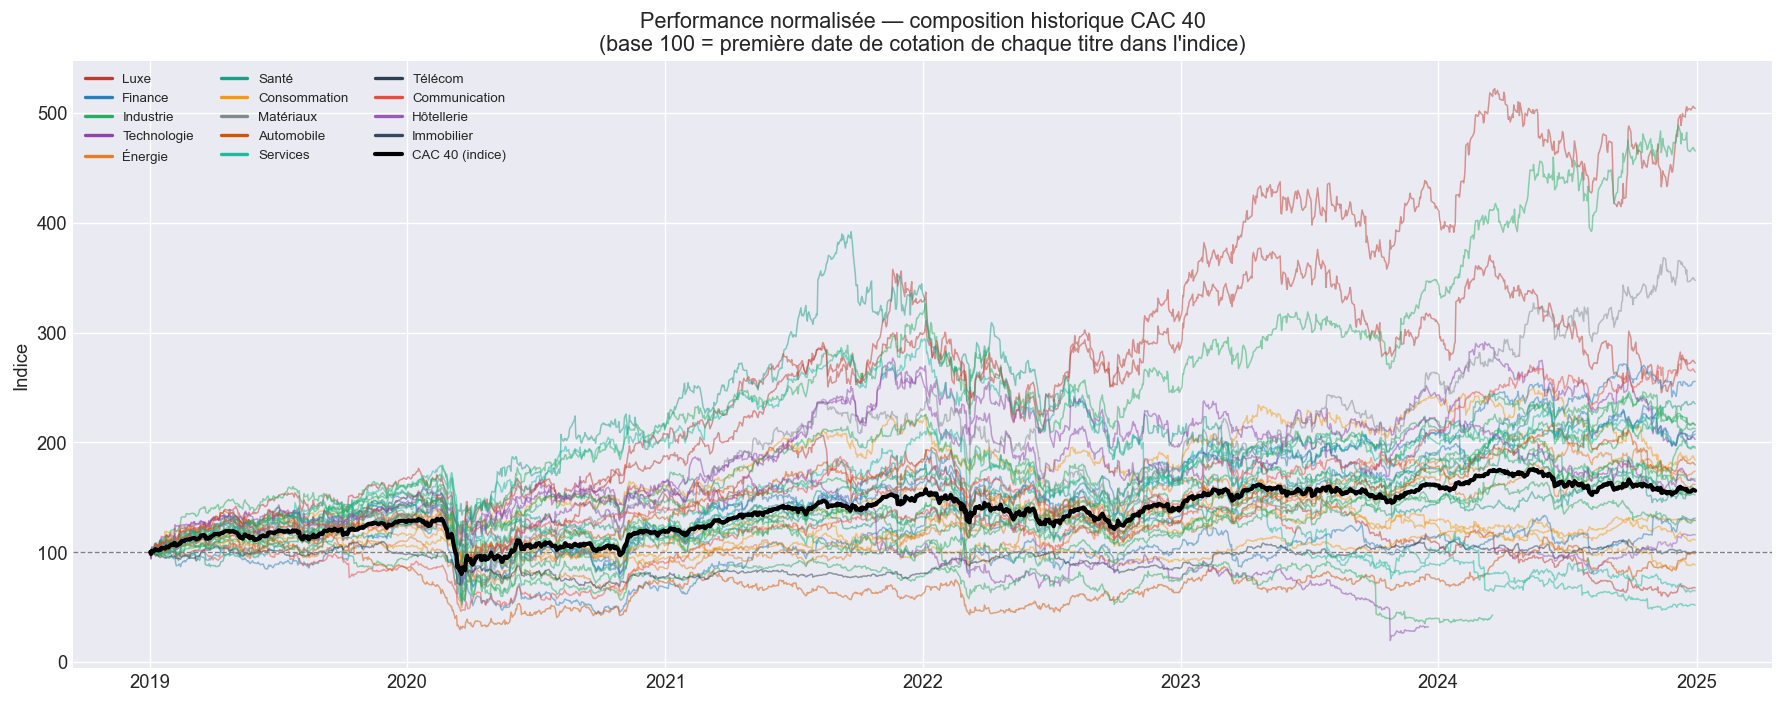

In [34]:
# Normalisation base 100 depuis la première cote disponible de chaque titre
base = prices[available].copy()
for col in base.columns:
    fv = base[col].first_valid_index()
    if fv is not None:
        base[col] = base[col] / base.loc[fv, col] * 100
base_cac = prices["CAC40"] / prices["CAC40"].iloc[0] * 100

from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(15, 6))
for ticker in available:
    sect  = sectors.get(ticker, "Autre")
    color = SECTOR_COLORS.get(sect, "gray")
    ax.plot(base.index, base[ticker], linewidth=0.9, alpha=0.5, color=color)

ax.plot(base_cac.index, base_cac, color="black", linewidth=2.5, label="CAC 40", zorder=5)
ax.axhline(100, color="gray", linestyle="--", linewidth=0.8)
ax.set_title("Performance normalisée — composition historique CAC 40\n"
             "(base 100 = première date de cotation de chaque titre dans l'indice)")
ax.set_ylabel("Indice")

legend_elems = [Line2D([0],[0], color=c, linewidth=2, label=s)
                for s, c in SECTOR_COLORS.items() if s in sectors.values]
legend_elems.append(Line2D([0],[0], color="black", linewidth=2.5, label="CAC 40 (indice)"))
ax.legend(handles=legend_elems, ncol=3, fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

## 3. Statistiques descriptives

In [35]:
RF_ANNUAL = 0.03
rf_daily  = RF_ANNUAL / 252

ann_ret = stock_ret.mean() * 252
ann_vol = stock_ret.std()  * np.sqrt(252)
sharpe  = ann_ret / ann_vol

stats = pd.DataFrame({
    "Rendement (%)":    (ann_ret * 100).round(2),
    "Volatilité (%)":   (ann_vol * 100).round(2),
    "Sharpe":           sharpe.round(2),
    "Secteur":          sectors,
}).sort_values("Sharpe", ascending=False)

print("Top 10 par Sharpe Ratio")
print(stats.head(10).to_string())
print("\nFlop 5")
print(stats.tail(5).to_string())

Top 10 par Sharpe Ratio
        Rendement (%)  Volatilité (%)  Sharpe        Secteur
RMS.PA          30.11           26.77    1.12           Luxe
SU.PA           29.07           27.73    1.05      Industrie
AC.PA           20.96           22.04    0.95     Hôtellerie
SGO.PA          25.46           31.62    0.81      Matériaux
CS.PA           18.80           26.12    0.72        Finance
AI.PA           14.75           20.58    0.72      Industrie
MC.PA           20.61           29.01    0.71           Luxe
PUB.PA          20.81           31.14    0.67  Communication
EL.PA           17.31           25.66    0.67          Santé
LR.PA           15.69           24.87    0.63      Industrie

Flop 5
          Rendement (%)  Volatilité (%)  Sharpe      Secteur
STM.PA              NaN             NaN     NaN  Technologie
MT.PA               NaN             NaN     NaN    Matériaux
URW.AS              NaN             NaN     NaN   Immobilier
UG.PA               NaN             NaN     NaN   Aut

## 4. Matrice de corrélation — Tous les titres (triée par secteur)

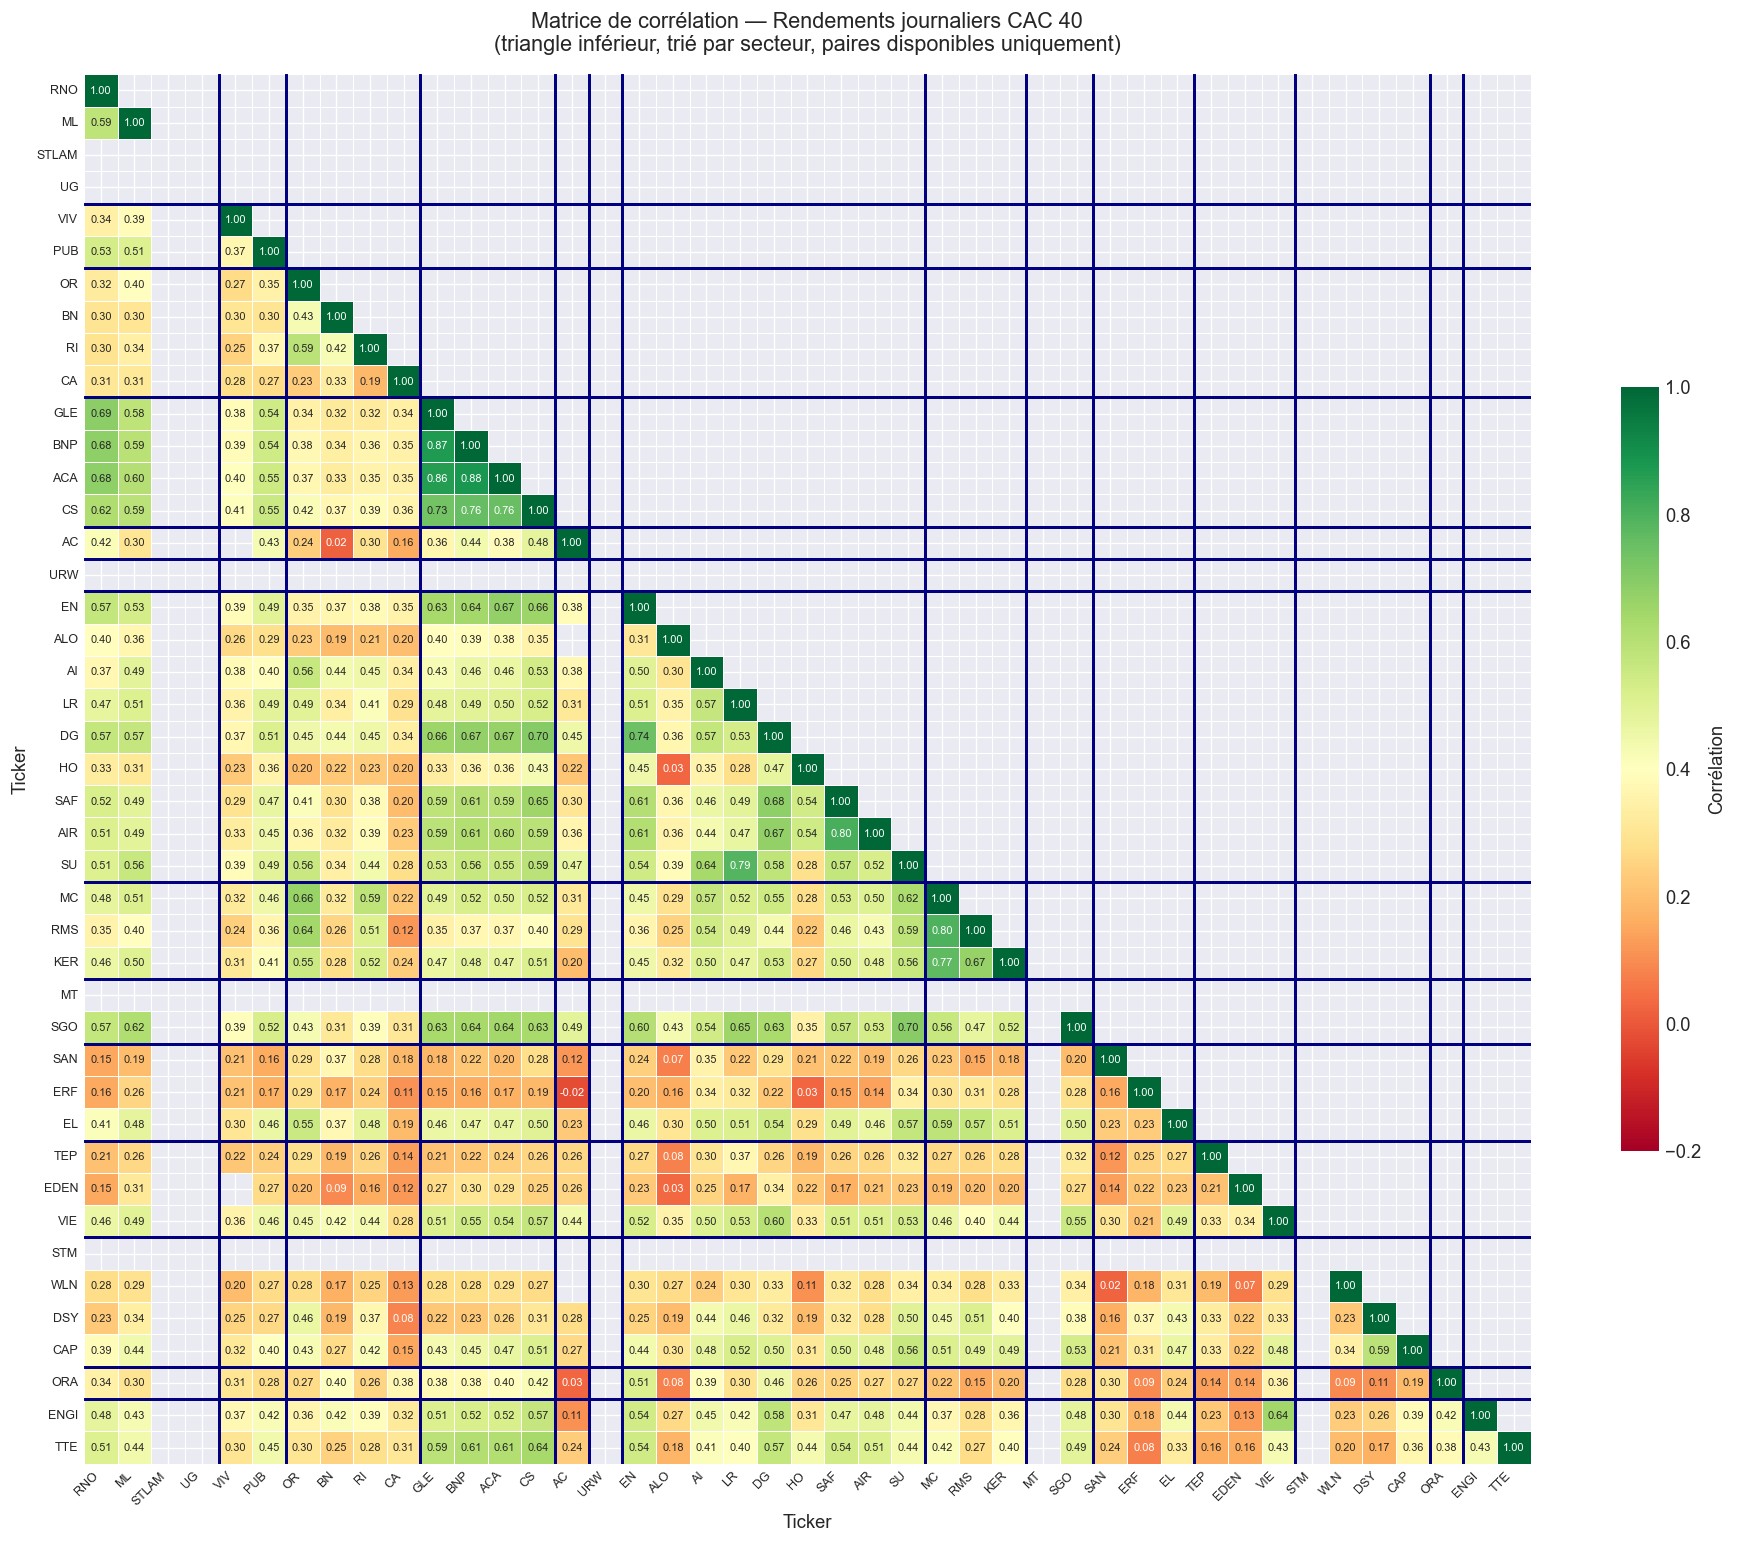

In [36]:
corr = stock_ret.corr()

order = sectors.sort_values().index.tolist()
order = [t for t in order if t in corr.index]
corr_sorted = corr.loc[order, order]
short_labels = [t.replace(".PA", "").replace(".AS", "") for t in order]

mask = np.triu(np.ones_like(corr_sorted, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(
    corr_sorted, mask=mask,
    cmap="RdYlGn", vmin=-0.2, vmax=1,
    annot=True, fmt=".2f", annot_kws={"size": 6.5},
    linewidths=0.3, linecolor="white",
    xticklabels=short_labels, yticklabels=short_labels,
    ax=ax, cbar_kws={"shrink": 0.55, "label": "Corrélation"}
)
ax.set_xticklabels(short_labels, rotation=45, ha="right", fontsize=7.5)
ax.set_yticklabels(short_labels, rotation=0, fontsize=7.5)
ax.set_title("Matrice de corrélation — Rendements journaliers CAC 40\n"
             "(triangle inférieur, trié par secteur, paires disponibles uniquement)", pad=14)

sect_vals = sectors[order].values
for i in range(1, len(sect_vals)):
    if sect_vals[i] != sect_vals[i-1]:
        ax.axhline(i, color="navy", linewidth=1.8)
        ax.axvline(i, color="navy", linewidth=1.8)

plt.tight_layout()
plt.show()

## 5. Corrélation inter-sectorielle

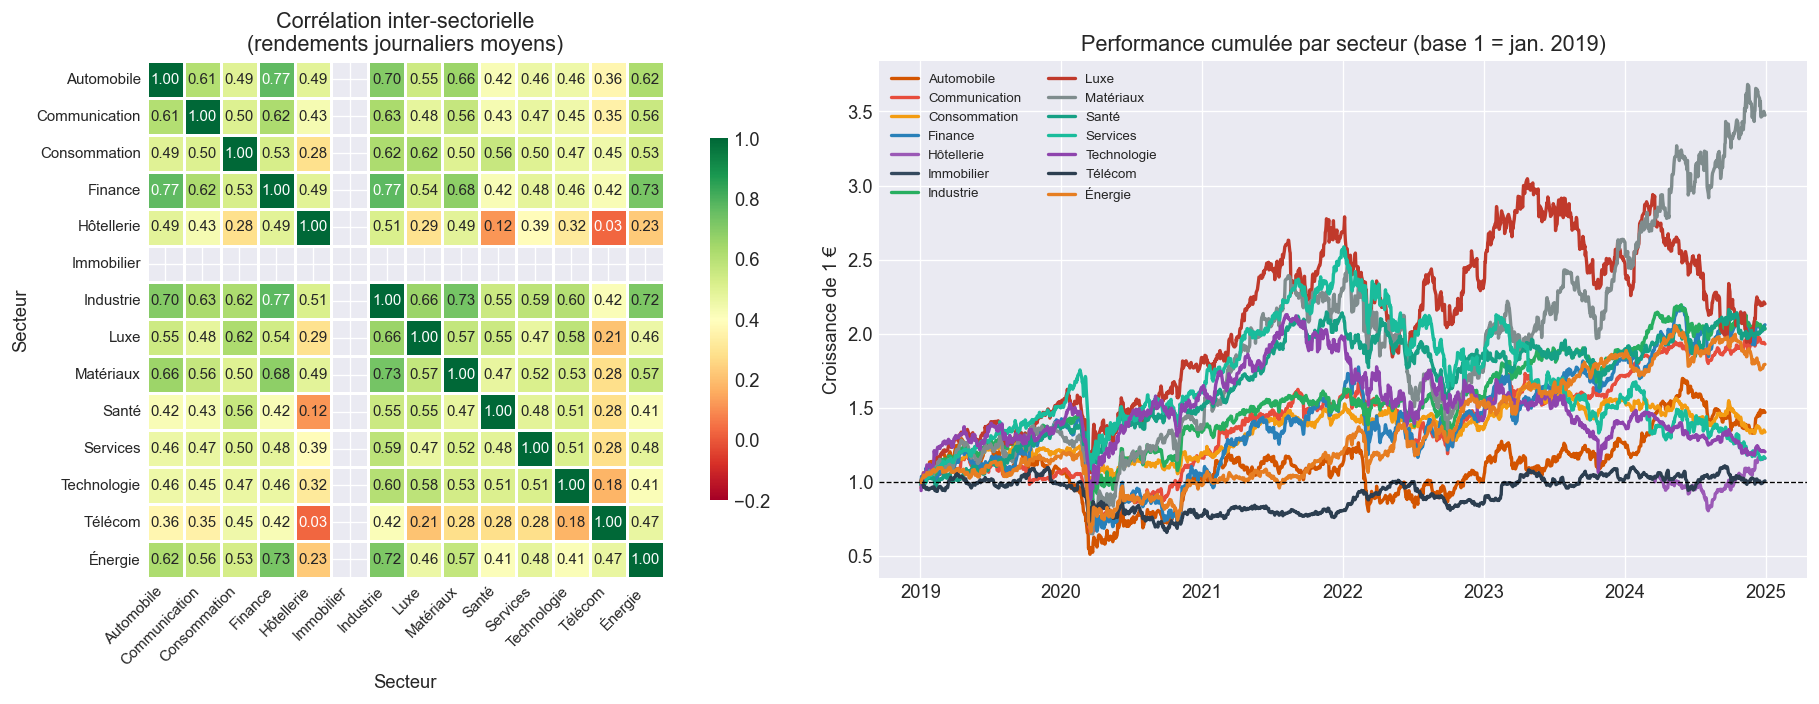

In [37]:
# Rendement moyen journalier par secteur
sect_daily = stock_ret.copy()
sect_daily.columns = sectors[sect_daily.columns]
sector_avg  = sect_daily.T.groupby(level=0).mean().T
sector_corr = sector_avg.corr()

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# ── A : heatmap corrélation sectorielle ─────────────────────────────────────
sns.heatmap(
    sector_corr, ax=axes[0],
    cmap="RdYlGn", vmin=-0.2, vmax=1,
    annot=True, fmt=".2f", annot_kws={"size": 9},
    linewidths=0.8, square=True,
    cbar_kws={"shrink": 0.7}
)
axes[0].set_title("Corrélation inter-sectorielle\n(rendements journaliers moyens)")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha="right", fontsize=9)
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0, fontsize=9)

# ── B : performance cumulée par secteur ─────────────────────────────────────
cumul_sector = (1 + sector_avg).cumprod()
for col in cumul_sector.columns:
    axes[1].plot(cumul_sector.index, cumul_sector[col],
                 linewidth=2, label=col, color=SECTOR_COLORS.get(col, "gray"))
axes[1].axhline(1, color="black", linestyle="--", linewidth=0.8)
axes[1].set_title("Performance cumulée par secteur (base 1 = jan. 2019)")
axes[1].set_ylabel("Croissance de 1 €")
axes[1].legend(ncol=2, fontsize=8)

plt.tight_layout()
plt.show()

## 6. Corrélation glissante 90 jours avec le CAC 40

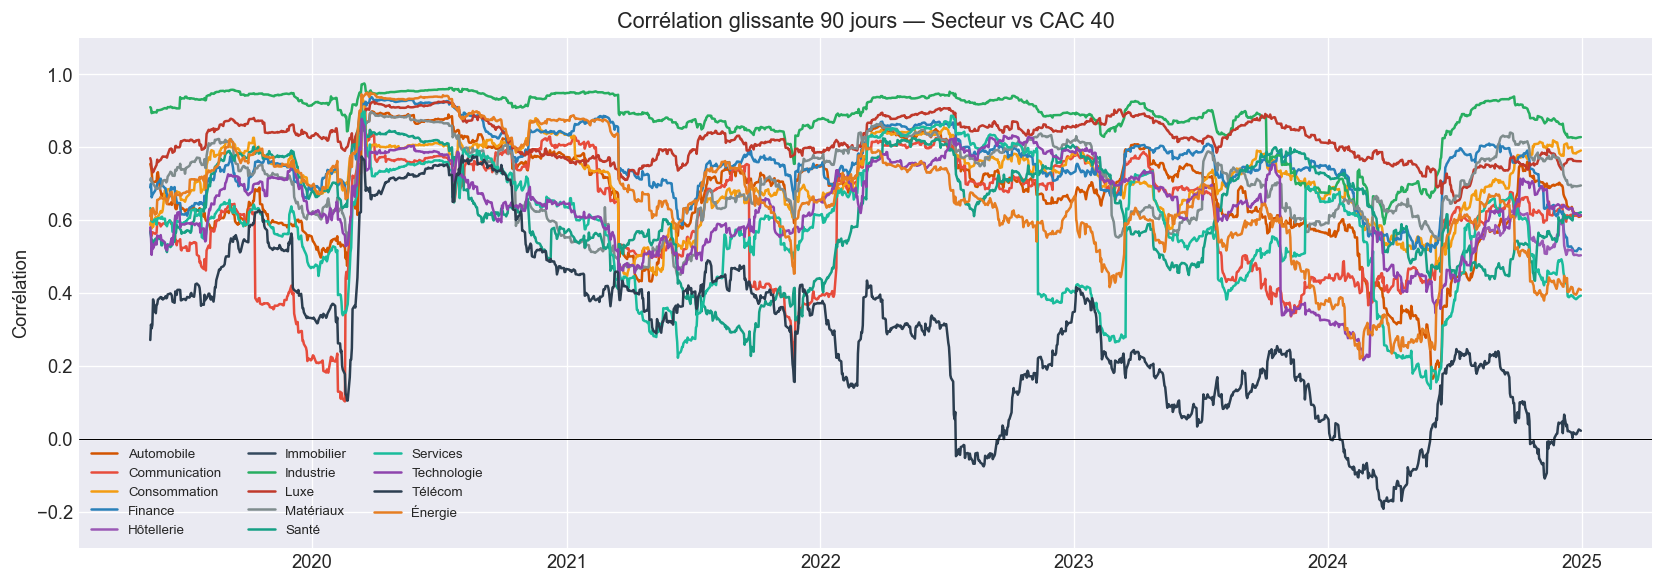

In [38]:
roll_corr = pd.DataFrame({
    s: sector_avg[s].rolling(90).corr(market_ret)
    for s in sector_avg.columns
}).dropna(how="all")

fig, ax = plt.subplots(figsize=(14, 5))
for s in roll_corr.columns:
    ax.plot(roll_corr.index, roll_corr[s], linewidth=1.5,
            label=s, color=SECTOR_COLORS.get(s, "gray"))
ax.axhline(0, color="black", linewidth=0.6)
ax.set_ylim(-0.3, 1.1)
ax.set_title("Corrélation glissante 90 jours — Secteur vs CAC 40")
ax.set_ylabel("Corrélation")
ax.legend(ncol=3, fontsize=8)
plt.tight_layout()
plt.show()

## 7. CAPM — Beta et Alpha de Jensen

$$r_i - r_f = \alpha_i + \beta_i\,(r_m - r_f) + \varepsilon_i$$

- **β > 1** : titre cyclique, amplifie les mouvements du marché
- **β < 1** : titre défensif, amortit les chocs
- **α > 0** : surperformance résiduelle non rémunérée par le risque systématique

In [39]:
excess_market = market_ret - rf_daily
capm_results  = {}

for ticker in available:
    sr = (stock_ret[ticker] - rf_daily).dropna()
    if len(sr) < 100:
        continue
    mkt   = excess_market.reindex(sr.index)
    model = sm.OLS(sr, sm.add_constant(mkt)).fit()
    capm_results[ticker] = {
        "alpha_ann": model.params["const"] * 252,
        "beta":      model.params["CAC40"],
        "r2":        model.rsquared,
        "p_alpha":   model.pvalues["const"],
    }

capm_df = pd.DataFrame(capm_results).T
capm_df["secteur"]      = sectors
capm_df["ticker_short"] = capm_df.index.str.replace(r"\.(PA|AS)$", "", regex=True)

print("CAPM results — triés par beta décroissant")
print(capm_df[["secteur","beta","alpha_ann","r2"]].round(4)
      .sort_values("beta", ascending=False).to_string())

CAPM results — triés par beta décroissant
               secteur    beta  alpha_ann      r2
RNO.PA      Automobile  1.5322    -0.0273  0.4458
GLE.PA         Finance  1.5314     0.0017  0.5439
AIR.PA       Industrie  1.4761     0.0648  0.5372
SAF.PA       Industrie  1.4480     0.0742  0.5668
BNP.PA         Finance  1.3383     0.0640  0.5923
SGO.PA       Matériaux  1.2303     0.1485  0.5727
KER.PA            Luxe  1.2227    -0.1170  0.5346
ACA.PA         Finance  1.2210     0.0657  0.5764
MC.PA             Luxe  1.2072     0.1013  0.6550
DG.PA        Industrie  1.1865     0.0220  0.6381
SU.PA        Industrie  1.1411     0.1901  0.6403
ALO.PA       Industrie  1.0758    -0.2158  0.1937
CS.PA          Finance  1.0648     0.0921  0.6287
TTE.PA         Énergie  1.0462     0.0295  0.4562
CAP.PA     Technologie  1.0293     0.0677  0.4379
EN.PA        Industrie  1.0095    -0.0130  0.5091
PUB.PA   Communication  1.0010     0.1161  0.3908
VIE.PA        Services  0.9728     0.0584  0.4685
ML.PA   

## 8. Security Market Line (SML)

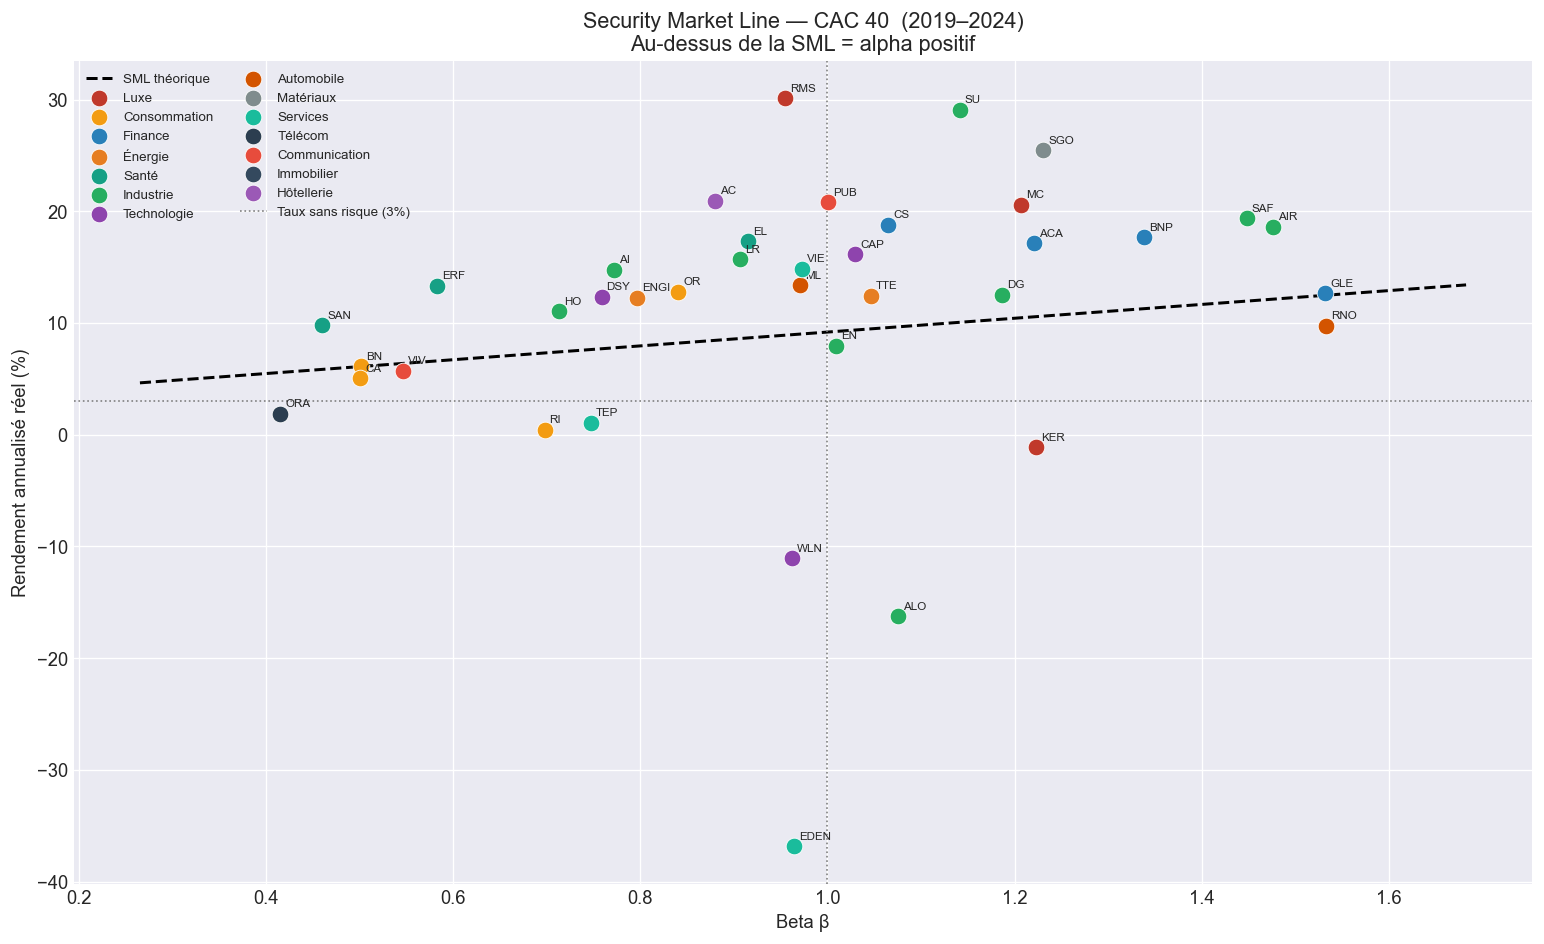

In [40]:
market_premium = float(market_ret.mean() * 252 - RF_ANNUAL)
beta_range     = np.linspace(capm_df["beta"].min() - 0.15,
                              capm_df["beta"].max() + 0.15, 200)

fig, ax = plt.subplots(figsize=(13, 8))
ax.plot(beta_range, (RF_ANNUAL + beta_range * market_premium) * 100,
        color="black", linewidth=1.8, linestyle="--",
        label="SML théorique", zorder=2)

for sect in sectors.unique():
    mask = capm_df["secteur"] == sect
    sub  = capm_df[mask]
    ax.scatter(sub["beta"], ann_ret[sub.index] * 100,
               color=SECTOR_COLORS.get(sect, "gray"),
               s=100, edgecolors="white", linewidths=0.5,
               zorder=3, label=sect)
    for _, row in sub.iterrows():
        ax.annotate(row["ticker_short"],
                    (row["beta"], ann_ret[row.name] * 100),
                    fontsize=7, ha="left", va="bottom",
                    xytext=(3, 3), textcoords="offset points")

ax.axhline(RF_ANNUAL * 100, color="gray", linestyle=":", linewidth=1,
           label=f"Taux sans risque ({RF_ANNUAL:.0%})")
ax.axvline(1, color="gray",  linestyle=":", linewidth=1)
ax.set_title("Security Market Line — CAC 40  (2019–2024)\n"
             "Au-dessus de la SML = alpha positif")
ax.set_xlabel("Beta β")
ax.set_ylabel("Rendement annualisé réel (%)")
ax.legend(ncol=2, fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

## 9. Heatmaps CAPM — Beta et Alpha par secteur

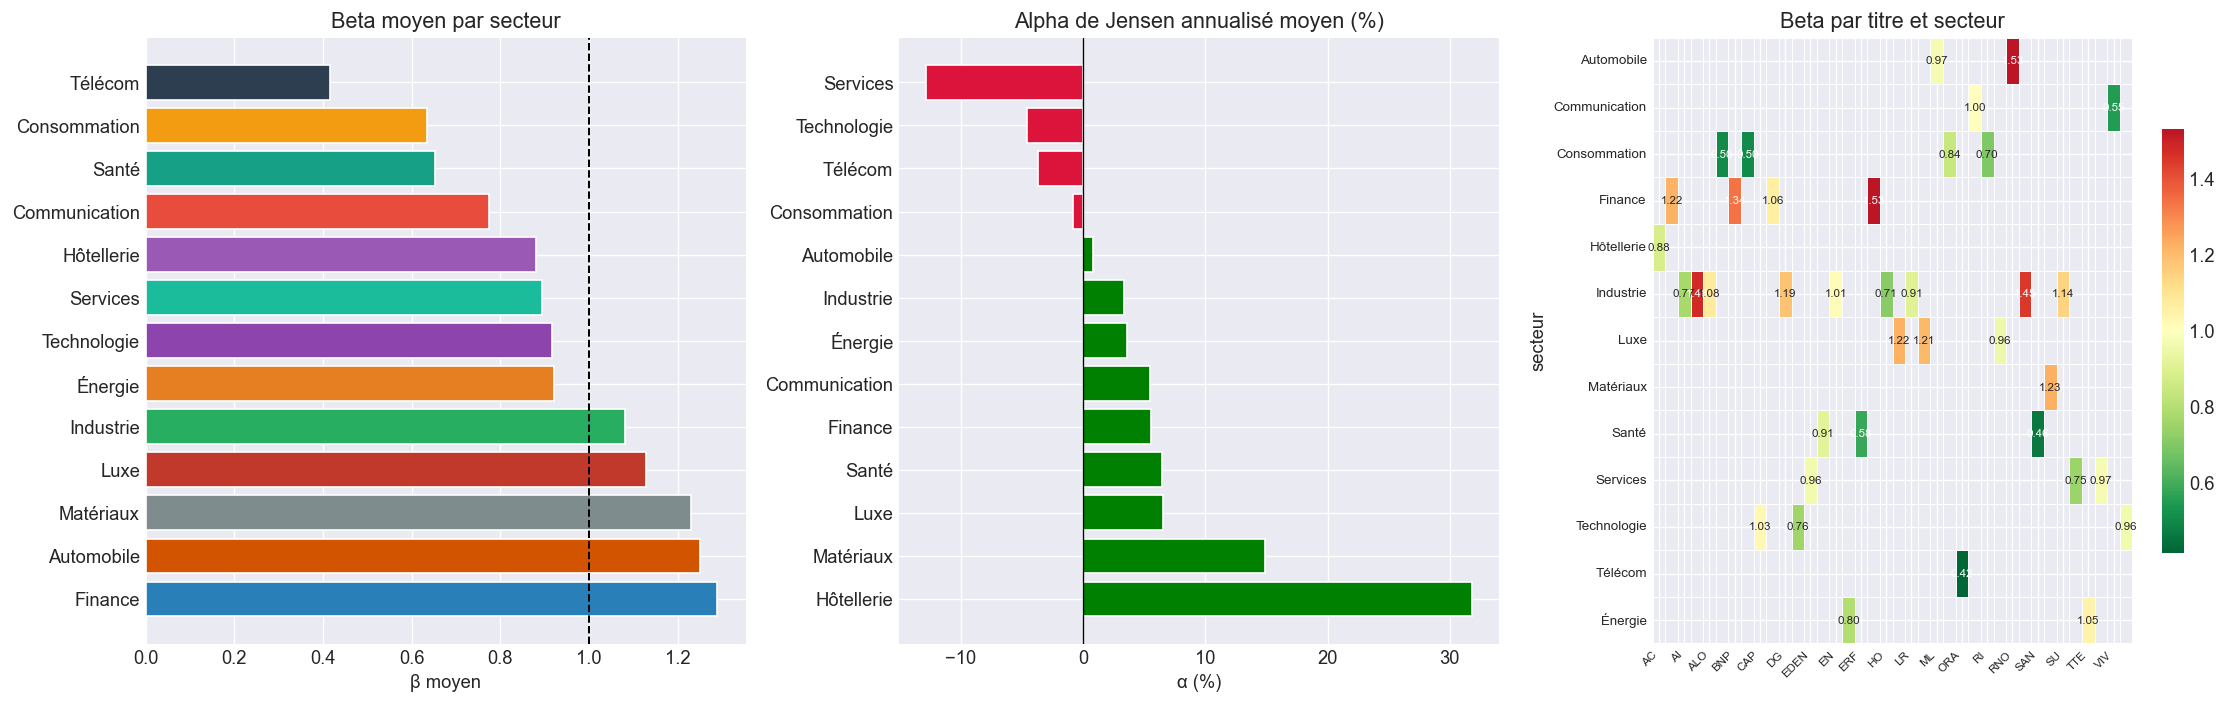

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(19, 6))

# ── A : beta moyen par secteur ──────────────────────────────────────────────
beta_by_sect  = capm_df.groupby("secteur")["beta"].mean().sort_values(ascending=False)
axes[0].barh(beta_by_sect.index, beta_by_sect.values,
             color=[SECTOR_COLORS.get(s,"gray") for s in beta_by_sect.index],
             edgecolor="white")
axes[0].axvline(1, color="black", linestyle="--", linewidth=1.2)
axes[0].set_title("Beta moyen par secteur")
axes[0].set_xlabel("β moyen")

# ── B : alpha moyen par secteur ──────────────────────────────────────────────
alpha_by_sect = capm_df.groupby("secteur")["alpha_ann"].mean().sort_values(ascending=False)
axes[1].barh(alpha_by_sect.index, alpha_by_sect.values * 100,
             color=["green" if v > 0 else "crimson" for v in alpha_by_sect.values],
             edgecolor="white")
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Alpha de Jensen annualisé moyen (%)")
axes[1].set_xlabel("α (%)")

# ── C : heatmap beta titre × secteur ────────────────────────────────────────
pivot = capm_df.pivot_table(index="secteur", columns="ticker_short",
                             values="beta", aggfunc="first")
pivot = pivot.reindex(sorted(pivot.index))
sns.heatmap(pivot, ax=axes[2], cmap="RdYlGn_r", center=1,
            annot=True, fmt=".2f", annot_kws={"size": 7},
            linewidths=0.4, cbar_kws={"shrink": 0.7},
            mask=pivot.isnull())
axes[2].set_title("Beta par titre et secteur")
axes[2].set_xlabel("")
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=45, ha="right", fontsize=7)
axes[2].set_yticklabels(axes[2].get_yticklabels(), rotation=0, fontsize=8)

plt.tight_layout()
plt.show()

## 10. Classement Alpha — Créateurs et destructeurs de valeur

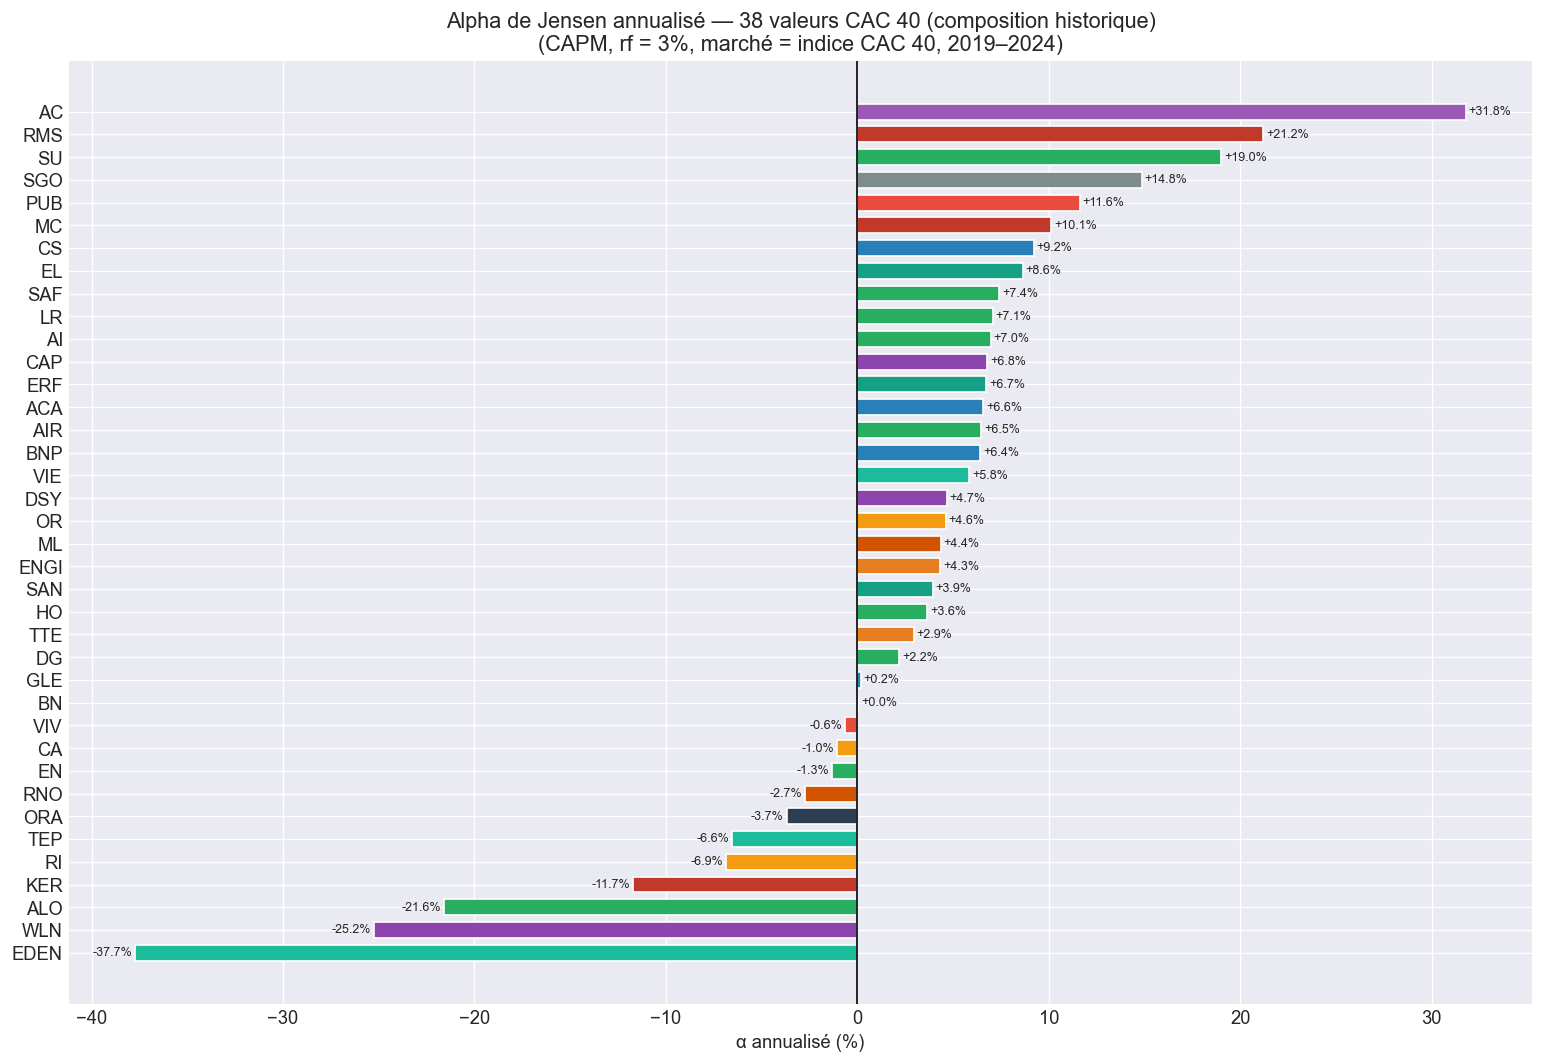

In [42]:
alpha_sorted = capm_df.sort_values("alpha_ann")

fig, ax = plt.subplots(figsize=(13, 9))
bar_colors = [SECTOR_COLORS.get(alpha_sorted.loc[i,"secteur"],"gray")
              for i in alpha_sorted.index]
bars = ax.barh(alpha_sorted["ticker_short"], alpha_sorted["alpha_ann"] * 100,
               color=bar_colors, edgecolor="white", height=0.7)
ax.axvline(0, color="black", linewidth=1)

for bar, val in zip(bars, alpha_sorted["alpha_ann"] * 100):
    ax.text(val + (0.15 if val >= 0 else -0.15),
            bar.get_y() + bar.get_height() / 2,
            f"{val:+.1f}%", va="center",
            ha="left" if val >= 0 else "right", fontsize=7.5)

n = len(alpha_sorted)
ax.set_title(f"Alpha de Jensen annualisé — {n} valeurs CAC 40 (composition historique)\n"
             "(CAPM, rf = 3%, marché = indice CAC 40, 2019–2024)")
ax.set_xlabel("α annualisé (%)")
plt.tight_layout()
plt.show()

## 11. Fama-French 3 Facteurs — Europe

$$r_i - r_f = \alpha_i + \beta_i^{Mkt}(r_m-r_f) + \beta_i^{SMB}\cdot SMB + \beta_i^{HML}\cdot HML + \varepsilon_i$$

| Facteur | Signification | Implication pratique |
|---------|--------------|----------------------|
| **Mkt-RF** | Prime de risque marché | Risque systématique |
| **SMB** | *Small Minus Big* — petites caps vs grandes caps | Exposition à l'effet taille |
| **HML** | *High Minus Low* — valeur vs croissance | Exposition à l'effet valeur (book-to-market) |

In [43]:
try:
    import pandas_datareader.data as web
    ff_raw = web.DataReader("Europe_3_Factors_Daily", "famafrench",
                             start=START, end=END)
    ff = ff_raw[0].copy() / 100
    ff.index = ff.index.to_timestamp()   # PeriodIndex → DatetimeIndex
    ff.columns = ["Mkt-RF", "SMB", "HML", "RF"]
    print(f"✅ Facteurs FF Europe Daily téléchargés : {len(ff)} obs.")
    FF_SOURCE = "Fama-French Europe Daily — Ken French Data Library"

except Exception as e:
    print(f"⚠️  Téléchargement FF échoué ({e})\n   → Construction de proxies depuis les données CAC 40")

    vol_rank = stock_ret.std().rank()
    small_t  = vol_rank.nlargest(10).index
    large_t  = vol_rank.nsmallest(10).index

    first_px = prices[available].apply(lambda x: x.dropna().iloc[0]  if x.notna().any() else np.nan)
    last_px  = prices[available].apply(lambda x: x.dropna().iloc[-1] if x.notna().any() else np.nan)
    momentum = (last_px / first_px - 1).dropna()
    value_t  = momentum.nsmallest(10).index
    growth_t = momentum.nlargest(10).index

    ff = pd.DataFrame({
        "Mkt-RF": market_ret - rf_daily,
        "SMB":    stock_ret[small_t].mean(axis=1)  - stock_ret[large_t].mean(axis=1),
        "HML":    stock_ret[value_t].mean(axis=1)  - stock_ret[growth_t].mean(axis=1),
        "RF":     rf_daily,
    }, index=market_ret.index)
    FF_SOURCE = "Proxies construits depuis les données CAC 40"

print(f"Source : {FF_SOURCE}")

✅ Facteurs FF Europe Daily téléchargés : 1566 obs.
Source : Fama-French Europe Daily — Ken French Data Library


In [44]:
common = stock_ret.index.intersection(ff.index)
sr_ff  = stock_ret.loc[common]
fa     = ff.loc[common]

ff_results = {}
for ticker in available:
    valid = sr_ff[ticker].dropna()
    if len(valid) < 100:
        continue
    y       = valid - fa.loc[valid.index, "RF"]
    factors = fa.loc[valid.index, ["Mkt-RF", "SMB", "HML"]]
    model   = sm.OLS(y, sm.add_constant(factors)).fit()
    ff_results[ticker] = {
        "alpha_ann":  model.params["const"] * 252,
        "beta_mkt":   model.params["Mkt-RF"],
        "beta_smb":   model.params["SMB"],
        "beta_hml":   model.params["HML"],
        "r2_adj":     model.rsquared_adj,
    }

ff_df = pd.DataFrame(ff_results).T
ff_df["secteur"]      = sectors
ff_df["ticker_short"] = ff_df.index.str.replace(r"\.(PA|AS)$", "", regex=True)

print("Fama-French — Top 10 alpha annualisé")
print(ff_df[["secteur","alpha_ann","beta_mkt","beta_smb","beta_hml","r2_adj"]]
      .round(4).sort_values("alpha_ann", ascending=False).head(10).to_string())

Fama-French — Top 10 alpha annualisé
              secteur  alpha_ann  beta_mkt  beta_smb  beta_hml  r2_adj
RMS.PA           Luxe     0.2098    0.8679   -0.8360   -0.9615  0.5526
AC.PA      Hôtellerie     0.2017    0.8458   -0.3032    0.1926  0.2417
SU.PA       Industrie     0.1786    1.0650   -0.6652   -0.3709  0.5934
SGO.PA      Matériaux     0.1342    1.2272   -0.0054    0.4018  0.5404
PUB.PA  Communication     0.1025    0.9215   -0.1421    0.5750  0.3597
MC.PA            Luxe     0.0903    1.0437   -0.9774   -0.5571  0.5862
EL.PA           Santé     0.0809    0.7843   -0.6706   -0.3672  0.4082
ERF.PA          Santé     0.0746    0.7087   -0.0522   -0.9259  0.2034
CAP.PA    Technologie     0.0699    1.0799    0.1109   -0.3743  0.4252
CS.PA         Finance     0.0684    0.9048   -0.4651    0.8926  0.6373


## 12. Heatmap des chargements Fama-French — Tous les titres

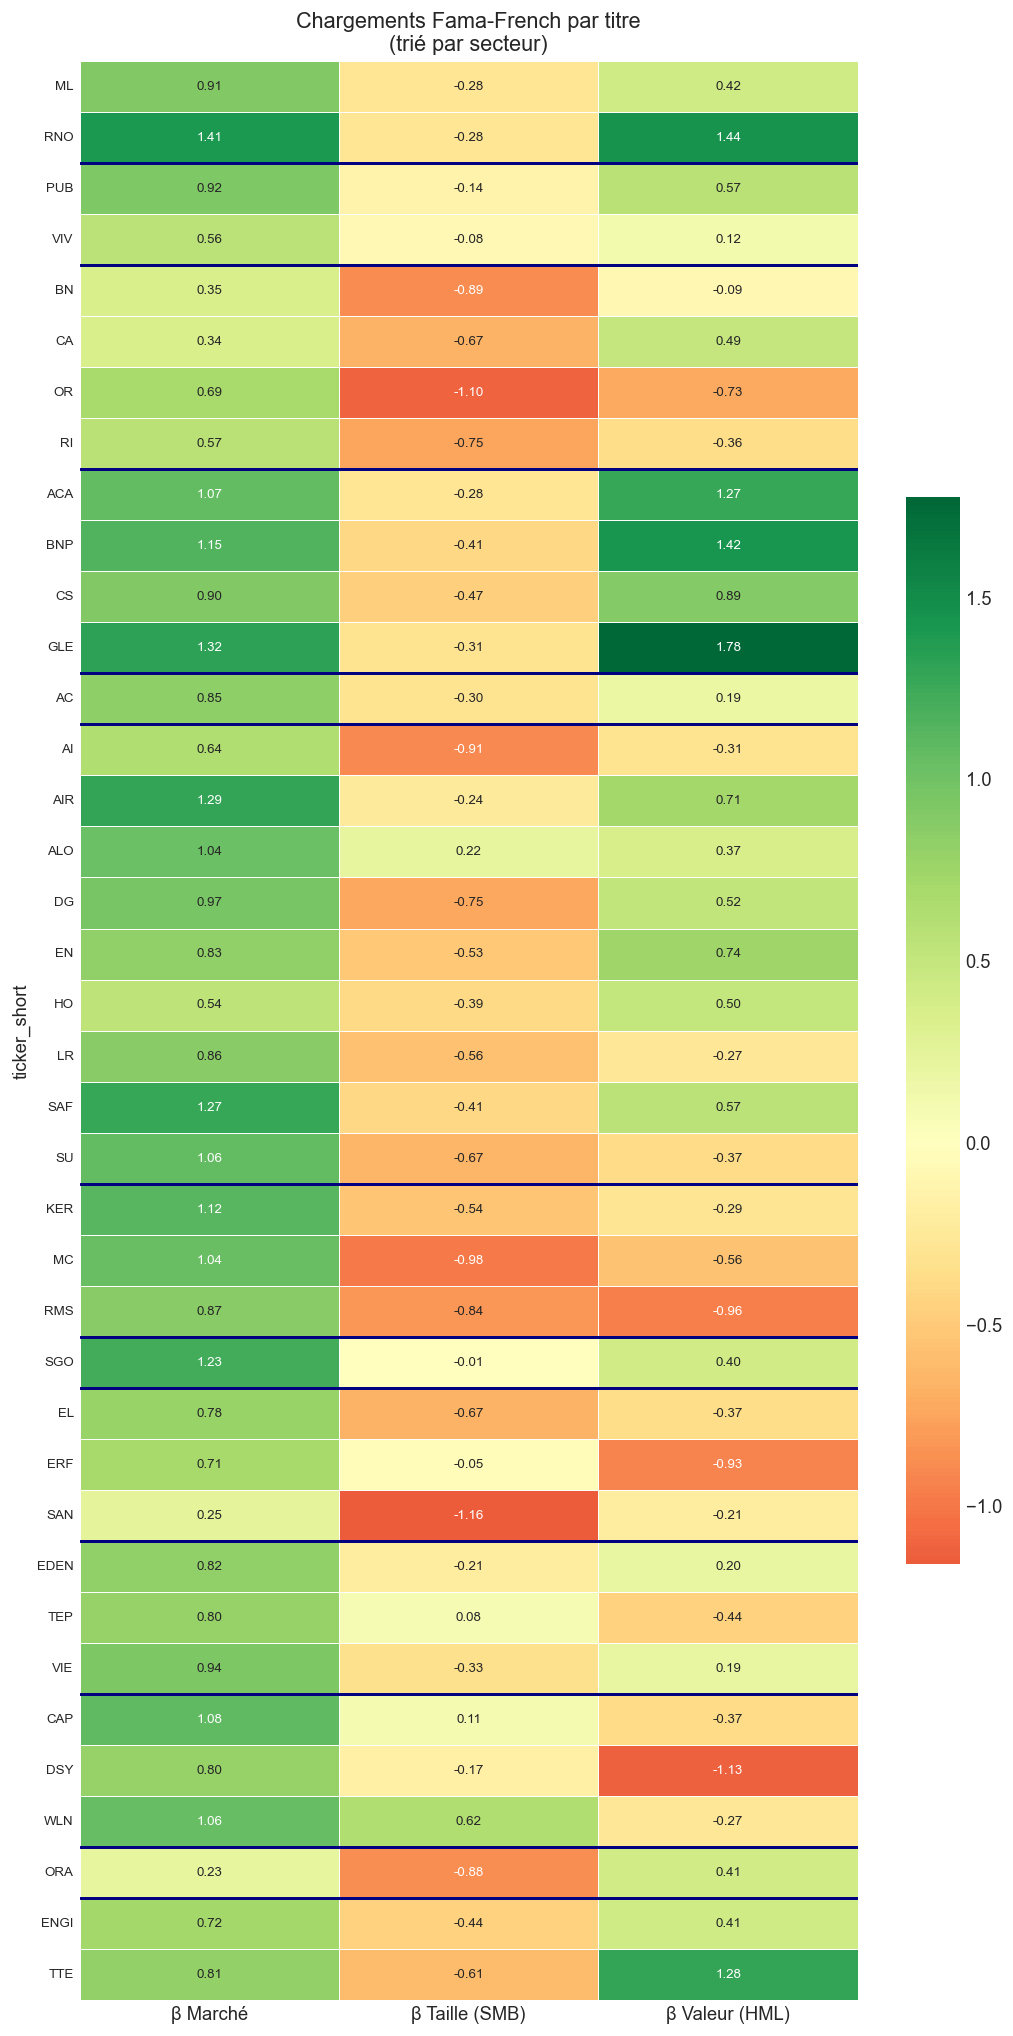

In [45]:
# Trier par secteur
ff_sorted = ff_df.sort_values(["secteur","ticker_short"])
lm = ff_sorted.set_index("ticker_short")[["beta_mkt","beta_smb","beta_hml"]]
lm.columns = ["β Mkt-RF", "β SMB", "β HML"]

fig, ax = plt.subplots(figsize=(9, max(8, len(lm) * 0.45)))
sns.heatmap(lm, ax=ax, cmap="RdYlGn", center=0,
            annot=True, fmt=".2f", annot_kws={"size": 8},
            linewidths=0.5, cbar_kws={"shrink": 0.55})
ax.set_title("Chargements Fama-French par titre\n(trié par secteur)")
ax.set_xticklabels(["β Marché", "β Taille (SMB)", "β Valeur (HML)"], rotation=0)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

# Séparateurs secteur
sv = ff_sorted["secteur"].values
for i in range(1, len(sv)):
    if sv[i] != sv[i-1]:
        ax.axhline(i, color="navy", linewidth=1.8)

plt.tight_layout()
plt.show()

## 13. Heatmap des chargements moyens par secteur

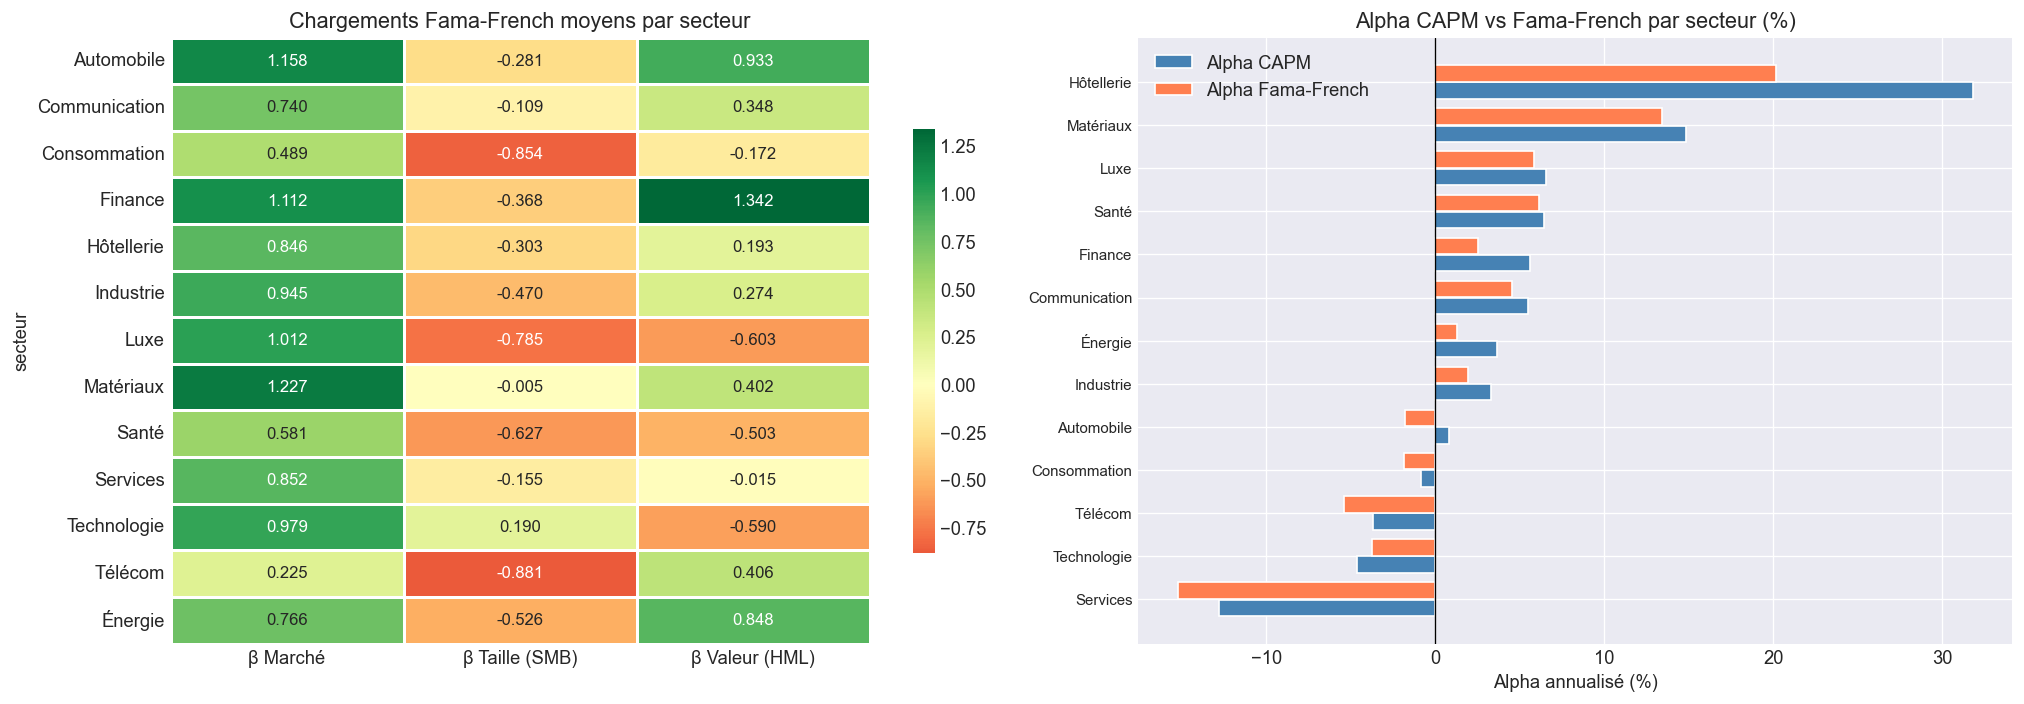

In [46]:
load_sect = ff_df.groupby("secteur")[["beta_mkt","beta_smb","beta_hml","alpha_ann"]].mean()
load_sect.columns = ["β Mkt-RF", "β SMB", "β HML", "α ann."]
load_sect["α ann."] *= 100

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# ── A : chargements β ────────────────────────────────────────────────────────
sns.heatmap(load_sect.drop(columns="α ann."), ax=axes[0],
            cmap="RdYlGn", center=0, annot=True, fmt=".3f",
            annot_kws={"size": 10}, linewidths=0.8,
            cbar_kws={"shrink": 0.7})
axes[0].set_title("Chargements Fama-French moyens par secteur")
axes[0].set_xticklabels(["β Marché", "β Taille (SMB)", "β Valeur (HML)"], rotation=0)
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0)

# ── B : alpha CAPM vs FF ─────────────────────────────────────────────────────
a_comp = pd.DataFrame({
    "CAPM (%)":         capm_df.groupby("secteur")["alpha_ann"].mean() * 100,
    "Fama-French (%)":  load_sect["α ann."],
}).sort_values("CAPM (%)")

x = np.arange(len(a_comp))
axes[1].barh(x - 0.2, a_comp["CAPM (%)"],         0.38, label="Alpha CAPM",
             color="steelblue", edgecolor="white")
axes[1].barh(x + 0.2, a_comp["Fama-French (%)"],  0.38, label="Alpha Fama-French",
             color="coral",     edgecolor="white")
axes[1].set_yticks(x)
axes[1].set_yticklabels(a_comp.index, fontsize=9)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Alpha CAPM vs Fama-French par secteur (%)")
axes[1].set_xlabel("Alpha annualisé (%)")
axes[1].legend()

plt.tight_layout()
plt.show()

## 14. Tableau de bord final — 6 panneaux

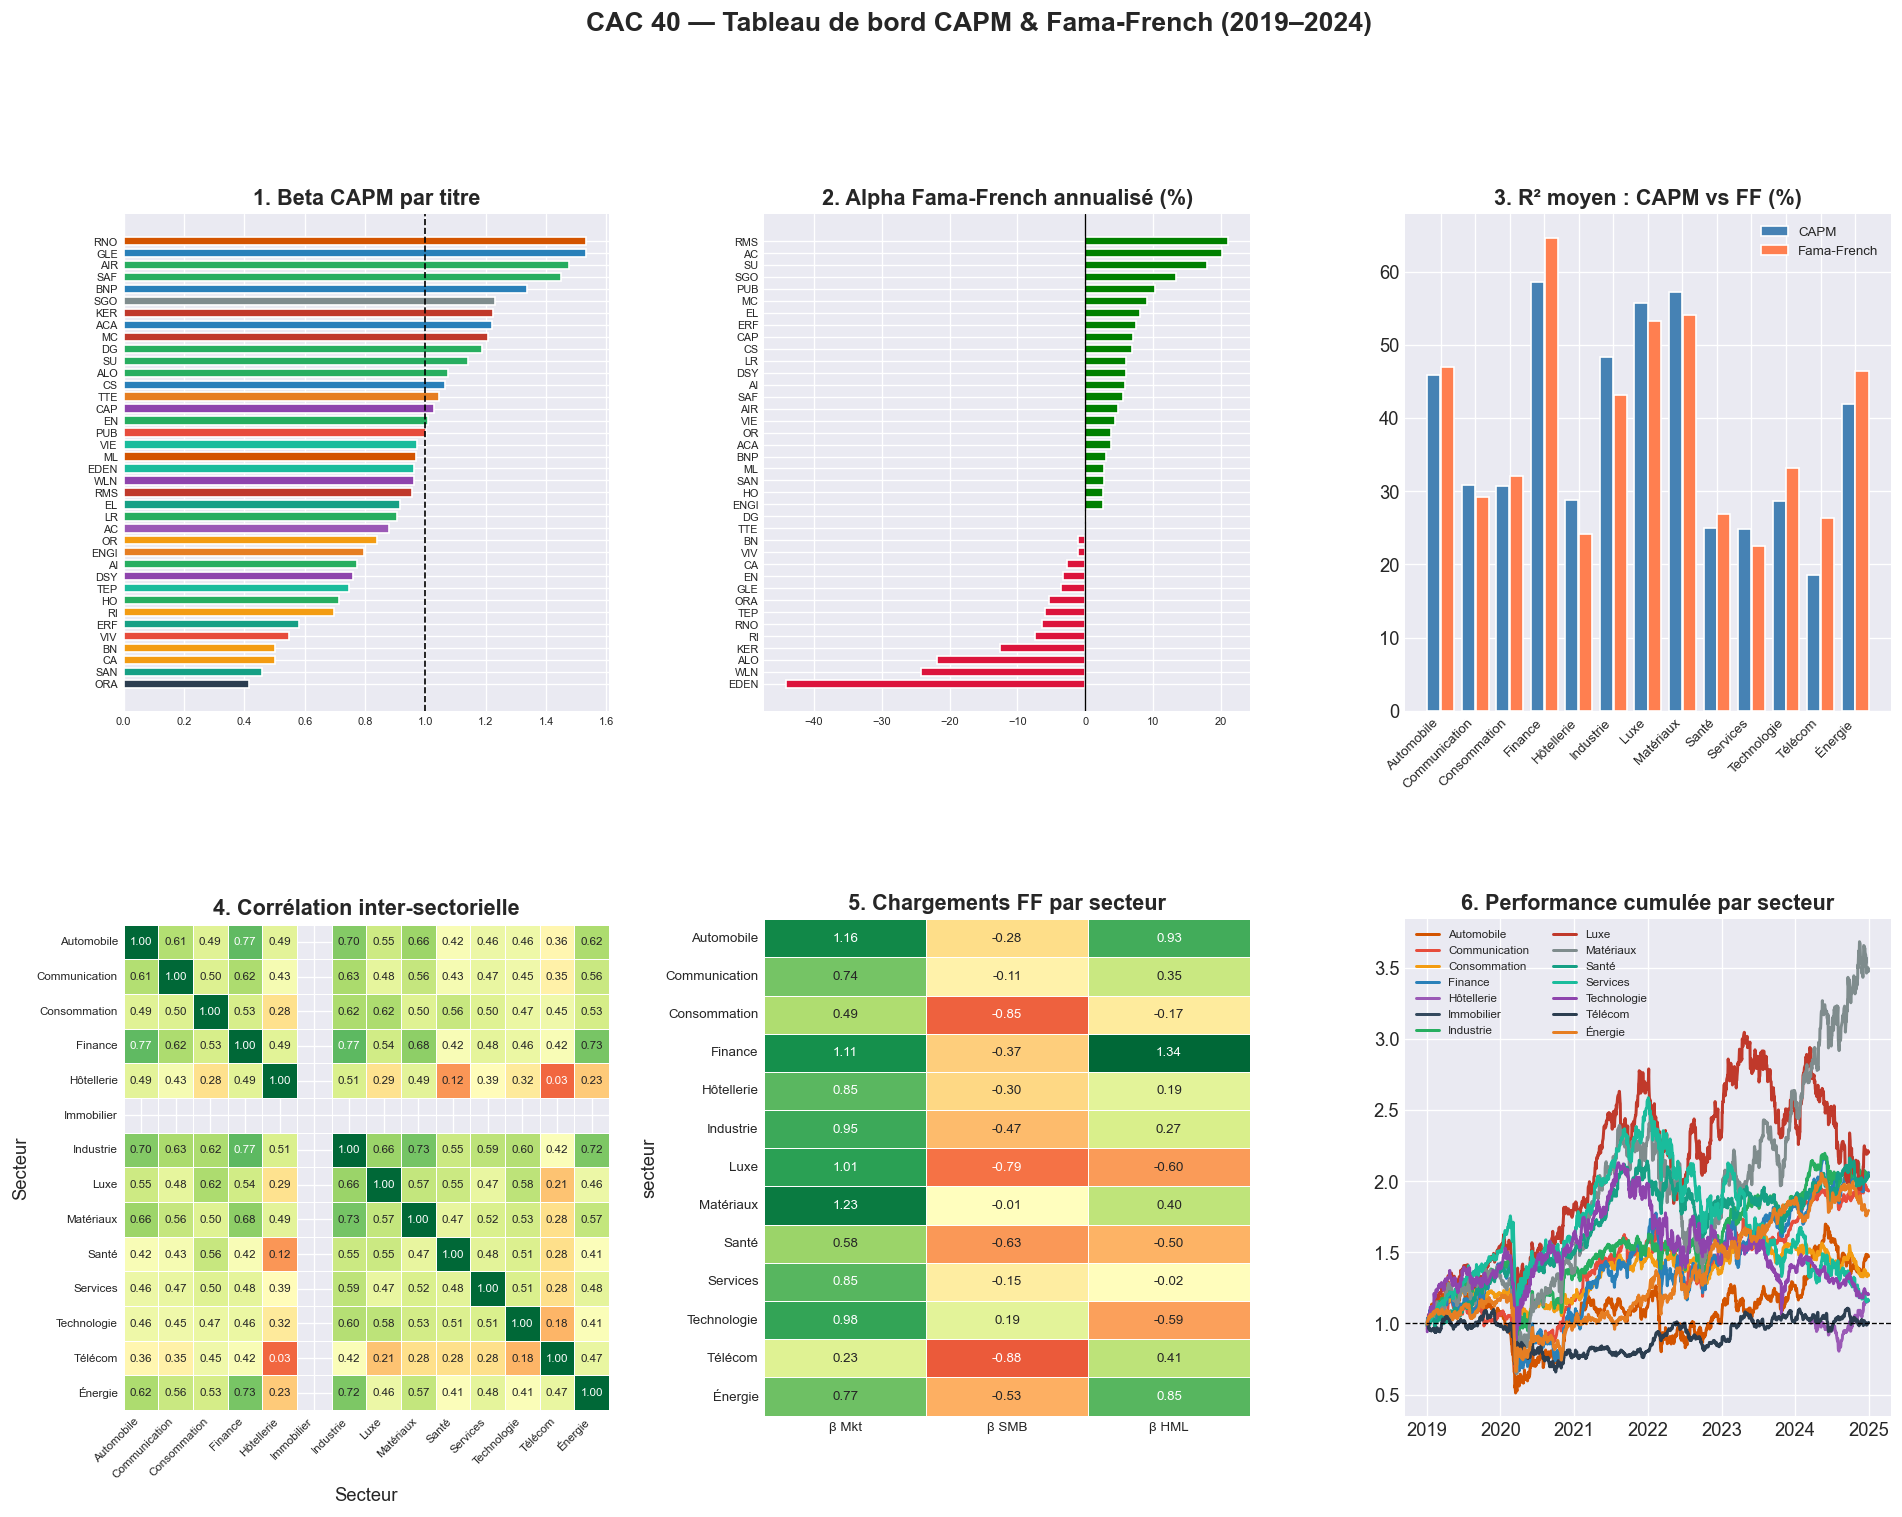

In [47]:
r2_comp = pd.DataFrame({
    "R² CAPM":         capm_df.groupby("secteur")["r2"].mean(),
    "R² Fama-French":  ff_df.groupby("secteur")["r2_adj"].mean(),
})

fig = plt.figure(figsize=(19, 13))
gs  = gridspec.GridSpec(2, 3, hspace=0.42, wspace=0.32)

# ── 1 : beta par titre ───────────────────────────────────────────────────────
ax1  = fig.add_subplot(gs[0, 0])
cd   = capm_df.sort_values("beta")
ax1.barh(cd["ticker_short"], cd["beta"],
         color=[SECTOR_COLORS.get(r["secteur"],"gray") for _,r in cd.iterrows()],
         edgecolor="white", height=0.7)
ax1.axvline(1, color="black", linestyle="--", linewidth=1)
ax1.set_title("1. Beta CAPM par titre", fontweight="bold")
ax1.tick_params(labelsize=6.5)

# ── 2 : alpha FF par titre ───────────────────────────────────────────────────
ax2  = fig.add_subplot(gs[0, 1])
fd   = ff_df.sort_values("alpha_ann")
ax2.barh(fd["ticker_short"], fd["alpha_ann"] * 100,
         color=["green" if v > 0 else "crimson" for v in fd["alpha_ann"]],
         edgecolor="white", height=0.7)
ax2.axvline(0, color="black", linewidth=0.8)
ax2.set_title("2. Alpha Fama-French annualisé (%)", fontweight="bold")
ax2.tick_params(labelsize=6.5)

# ── 3 : R² CAPM vs FF par secteur ────────────────────────────────────────────
ax3  = fig.add_subplot(gs[0, 2])
x3   = np.arange(len(r2_comp))
ax3.bar(x3-0.2, r2_comp["R² CAPM"]*100,        0.38, label="CAPM",         color="steelblue", edgecolor="white")
ax3.bar(x3+0.2, r2_comp["R² Fama-French"]*100, 0.38, label="Fama-French",  color="coral",     edgecolor="white")
ax3.set_xticks(x3)
ax3.set_xticklabels(r2_comp.index, rotation=45, ha="right", fontsize=8)
ax3.set_title("3. R² moyen : CAPM vs FF (%)", fontweight="bold")
ax3.legend(fontsize=8)

# ── 4 : corrélation sectorielle ──────────────────────────────────────────────
ax4  = fig.add_subplot(gs[1, 0])
sns.heatmap(sector_corr, ax=ax4, cmap="RdYlGn", vmin=-0.2, vmax=1,
            annot=True, fmt=".2f", annot_kws={"size": 7},
            linewidths=0.5, square=True, cbar=False)
ax4.set_title("4. Corrélation inter-sectorielle", fontweight="bold")
ax4.tick_params(labelsize=7)
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=45, ha="right")

# ── 5 : chargements FF sectoriels ────────────────────────────────────────────
ax5  = fig.add_subplot(gs[1, 1])
sns.heatmap(load_sect.drop(columns="α ann."), ax=ax5,
            cmap="RdYlGn", center=0, annot=True, fmt=".2f",
            annot_kws={"size": 8}, linewidths=0.5, cbar=False)
ax5.set_title("5. Chargements FF par secteur", fontweight="bold")
ax5.set_xticklabels(["β Mkt","β SMB","β HML"], rotation=0, fontsize=9)
ax5.tick_params(labelsize=8)

# ── 6 : performance cumulée sectorielle ──────────────────────────────────────
ax6  = fig.add_subplot(gs[1, 2])
for col in cumul_sector.columns:
    ax6.plot(cumul_sector.index, cumul_sector[col],
             linewidth=1.8, label=col, color=SECTOR_COLORS.get(col,"gray"))
ax6.axhline(1, color="black", linestyle="--", linewidth=0.8)
ax6.set_title("6. Performance cumulée par secteur", fontweight="bold")
ax6.legend(ncol=2, fontsize=7)

fig.suptitle("CAC 40 — Tableau de bord CAPM & Fama-French (2019–2024)",
             fontsize=16, fontweight="bold", y=1.01)
plt.show()